# Flyby Animation Pipeline — All Species & Conditions

Processes all marmoset and mouse 2D section folders.  
Untars archives, sorts sections anatomically, renders MP4 + GIF per folder.

| Species | Sort order | File pattern |
|---|---|---|
| Marmoset | block ↑, slice ↑ (rostral→caudal) | `CJ23.56.004.CX.<block>.<slice>.<stain>.png` |
| Mouse | section ↓ (high=rostral, low=caudal) | `C57BL6J-638850.<section>.png` |

## 0. Install dependencies

In [1]:
%matplotlib inline 

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'imageio[ffmpeg]', 'scikit-image', 'numpy',
                'matplotlib', 'pandas', '--quiet'], check=True)
print('Dependencies ready.')

Dependencies ready.


## 1. Configuration — edit here

In [5]:
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────
# Parent directory containing all .tar files
TAR_DIR     = Path('/root/capsule/code/data/abc_atlas/Sections')
EXTRACT_DIR = Path('/root/capsule/code/data/abc_atlas/Sections')

# Where videos and GIFs are saved
OUTPUT_DIR = Path('/root/capsule/code/abc_atlas_access/notebooks/flyby_videos_marmoset_coronal')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Video settings ─────────────────────────────────────────────────────────
FPS           = 3     # frames per second
RESIZE_FACTOR = 0.8   # 0.5 = half resolution; 1.0 = full

# ── Dataset registry ───────────────────────────────────────────────────────
# (tar_glob, species)  — glob handles (1) suffix from Windows duplicate downloads
DATASETS = [
    ('amex_clusters_marm_2d_all*.tar.gz',                          'marmoset'),
    ('amex_clusters_mouse_2d_all*.tar.gz',                         'mouse'),
    ('chronotype_bmi_exclusive_marm_2d_all*.tar.gz',               'marmoset'),
    ('chronotype_bmi_exclusive_mouse_2d_all*.tar.gz',              'mouse'),
    ('independent_clusters_bmi_yengo2018_marm_2d_all*.tar.gz',     'marmoset'),
    ('independent_clusters_bmi_yengo2018_mouse_2d_all*.tar.gz',    'mouse'),
    ('independent_clusters_chronotype_loh2018_ukb_marm_2d_all*.tar.gz',  'marmoset'),
    ('independent_clusters_chronotype_loh2018_ukb_mouse_2d_all*.tar.gz', 'mouse'),
    ('independent_clusters_scz_pgc3_2022_marm_2d_all*.tar.gz',     'marmoset'),
    ('independent_clusters_scz_pgc3_2022_mouse_2d_all*.tar.gz',    'mouse'),
]

print(f'TAR_DIR    : {TAR_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'FPS: {FPS}  |  Resize: {RESIZE_FACTOR}')
print(f'\nDatasets registered: {len(DATASETS)}')

TAR_DIR    : /root/capsule/code/data/abc_atlas/Sections
OUTPUT_DIR : /root/capsule/code/abc_atlas_access/notebooks/flyby_videos_marmoset_coronal
FPS: 3  |  Resize: 0.8

Datasets registered: 10


## 2. Untar all archives

In [6]:
import tarfile

def find_tar(tar_dir: Path, glob_pattern: str):
    """Find the first tar file matching the glob. Returns None if not found."""
    matches = sorted(tar_dir.glob(glob_pattern))
    if not matches:
        return None
    if len(matches) > 1:
        print(f'  [WARN] Multiple matches for {glob_pattern}: {[m.name for m in matches]}')
        print(f'         Using: {matches[0].name}')
    return matches[0]

def canonical_name(tar_path: Path) -> str:
    """Strip (1), (2) etc. from name to get clean folder name."""
    import re
    stem = tar_path.stem   # filename without .tar
    return re.sub(r'\s*\(\d+\)\s*$', '', stem).strip()

resolved = []   # list of (canon_name, species, extract_path)

print('=== Untarring archives ===')
for glob_pat, species in DATASETS:
    tar_path = find_tar(TAR_DIR, glob_pat)
    if tar_path is None:
        print(f'  [MISSING] No file found for: {glob_pat}')
        continue

    canon = canonical_name(tar_path)
    dest  = EXTRACT_DIR / canon

    if dest.exists() and any(dest.iterdir()):
        print(f'  [SKIP] Already extracted: {canon}')
    else:
        dest.mkdir(parents=True, exist_ok=True)
        print(f'  [UNTAR] {tar_path.name} → {dest}', end=' ... ', flush=True)
        with tarfile.open(tar_path, 'r:gz') as tf:
            tf.extractall(path=dest)
        print('done')

    resolved.append((canon, species, dest))

print(f'\nReady to process {len(resolved)} datasets.')

=== Untarring archives ===
  [UNTAR] amex_clusters_marm_2d_all.tar.gz → /root/capsule/code/data/abc_atlas/Sections/amex_clusters_marm_2d_all.tar ... done
  [UNTAR] amex_clusters_mouse_2d_all.tar.gz → /root/capsule/code/data/abc_atlas/Sections/amex_clusters_mouse_2d_all.tar ... done
  [UNTAR] chronotype_bmi_exclusive_marm_2d_all.tar.gz → /root/capsule/code/data/abc_atlas/Sections/chronotype_bmi_exclusive_marm_2d_all.tar ... done
  [UNTAR] chronotype_bmi_exclusive_mouse_2d_all.tar.gz → /root/capsule/code/data/abc_atlas/Sections/chronotype_bmi_exclusive_mouse_2d_all.tar ... done
  [UNTAR] independent_clusters_bmi_yengo2018_marm_2d_all(1).tar.gz → /root/capsule/code/data/abc_atlas/Sections/independent_clusters_bmi_yengo2018_marm_2d_all(1).tar ... done
  [UNTAR] independent_clusters_bmi_yengo2018_mouse_2d_all.tar.gz → /root/capsule/code/data/abc_atlas/Sections/independent_clusters_bmi_yengo2018_mouse_2d_all.tar ... done
  [UNTAR] independent_clusters_chronotype_loh2018_ukb_marm_2d_all(1).ta

## 3. Sorting helpers (species-aware)

In [7]:
import re

def collect_frames_marmoset(folder: Path):
    """
    CJ23.56.004.CX.<block>.<slice>.<stain>.png
    Sort: block ↑, slice ↑  →  rostral (42) to caudal (44)
    Both stains interleaved in anatomical order.
    """
    records = []
    # PNGs may be directly in folder or one level deeper
    pngs = list(folder.rglob('CJ23.56.004.CX.*.png'))
    for fpath in pngs:
        m = re.search(r'\.CX\.(\d+)\.(\d+)\.(\d+)\.png$', fpath.name)
        if not m:
            continue
        block, slc, stain = int(m.group(1)), int(m.group(2)), m.group(3)
        records.append({'block': block, 'slice': slc, 'stain': stain, 'path': fpath})
    records.sort(key=lambda r: (r['block'], r['slice']))
    return records


def collect_frames_mouse(folder: Path):
    """
    C57BL6J-638850.<section>.png
    Sort: section ↓  →  rostral (high number) to caudal (low number)
    """
    records = []
    pngs = list(folder.rglob('C57BL6J-638850.*.png'))
    for fpath in pngs:
        m = re.search(r'C57BL6J-638850\.(\d+)\.png$', fpath.name)
        if not m:
            continue
        section = int(m.group(1))
        records.append({'section': section, 'path': fpath})
    records.sort(key=lambda r: r['section'], reverse=True)  # high → low
    return records


def collect_frames(folder: Path, species: str):
    if species == 'marmoset':
        return collect_frames_marmoset(folder)
    else:
        return collect_frames_mouse(folder)

print('Sorting helpers defined.')

Sorting helpers defined.


## 4. Frame loading helper

In [8]:
import imageio.v3 as iio
import numpy as np
from skimage.transform import resize as sk_resize

def load_frame(fpath: Path, resize_factor: float = 1.0) -> np.ndarray:
    img = iio.imread(fpath)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[2] == 4:
        img = img[..., :3]
    if resize_factor != 1.0:
        h, w = img.shape[:2]
        img = (sk_resize(
            img,
            (max(2, int(h * resize_factor)),
             max(2, int(w * resize_factor))),
            anti_aliasing=True
        ) * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    return img

print('Frame loader defined.')

Frame loader defined.


## 5. Render function (MP4 + GIF)

In [9]:
import imageio

def render_flyby(dataset_name: str, species: str, records: list,
                 output_dir: Path, fps: int, resize: float):
    """
    Render MP4 and GIF for a single dataset. Returns paths.
    """
    safe_name = dataset_name.replace(' ', '_')
    video_path = output_dir / f'{safe_name}.mp4'
    gif_path   = output_dir / f'{safe_name}.gif'

    print(f'  Frames : {len(records)}')
    print(f'  Duration : ~{len(records)/fps:.1f}s at {fps} fps')

    # ── MP4 ──────────────────────────────────────────────────────────────
    print(f'  Rendering MP4 ...', end=' ', flush=True)
    with imageio.get_writer(str(video_path), fps=fps, codec='libx264',
                            quality=8, macro_block_size=1) as writer:
        for r in records:
            writer.append_data(load_frame(r['path'], resize))
    print(f'done  ({video_path.stat().st_size/1e6:.1f} MB)')

    # ── GIF ──────────────────────────────────────────────────────────────
    print(f'  Rendering GIF  ...', end=' ', flush=True)
    frames = [load_frame(r['path'], resize) for r in records]
    iio.imwrite(str(gif_path), frames, loop=0, duration=int(1000/fps))
    print(f'done  ({gif_path.stat().st_size/1e6:.1f} MB)')

    return video_path, gif_path

print('Render function defined.')

Render function defined.


## 6. Run all datasets

In [10]:
import pandas as pd
import traceback

summary_rows = []

for i, (canon, species, extract_path) in enumerate(resolved):
    print(f'\n[{i+1}/{len(resolved)}] {canon}  ({species})')
    print('─' * 70)

    try:
        records = collect_frames(extract_path, species)

        if len(records) == 0:
            print(f'  [WARN] No PNGs found in {extract_path} — skipping.')
            summary_rows.append({'dataset': canon, 'species': species,
                                  'frames': 0, 'status': 'NO PNGS FOUND',
                                  'mp4': '', 'gif': ''})
            continue

        video_path, gif_path = render_flyby(
            canon, species, records,
            OUTPUT_DIR, FPS, RESIZE_FACTOR
        )

        summary_rows.append({
            'dataset' : canon,
            'species' : species,
            'frames'  : len(records),
            'status'  : 'OK',
            'mp4'     : str(video_path),
            'gif'     : str(gif_path),
        })

    except Exception as e:
        print(f'  [ERROR] {e}')
        traceback.print_exc()
        summary_rows.append({'dataset': canon, 'species': species,
                              'frames': 0, 'status': f'ERROR: {e}',
                              'mp4': '', 'gif': ''})

print('\n' + '=' * 70)
print('ALL DONE')
print('=' * 70)


[1/10] amex_clusters_marm_2d_all.tar  (marmoset)
──────────────────────────────────────────────────────────────────────
  Frames : 46
  Duration : ~15.3s at 3 fps
  Rendering MP4 ... done  (12.4 MB)
  Rendering GIF  ... done  (17.2 MB)

[2/10] amex_clusters_mouse_2d_all.tar  (mouse)
──────────────────────────────────────────────────────────────────────
  Frames : 39
  Duration : ~13.0s at 3 fps
  Rendering MP4 ... done  (12.4 MB)
  Rendering GIF  ... done  (16.0 MB)

[3/10] chronotype_bmi_exclusive_marm_2d_all.tar  (marmoset)
──────────────────────────────────────────────────────────────────────
  Frames : 47
  Duration : ~15.7s at 3 fps
  Rendering MP4 ... done  (12.5 MB)
  Rendering GIF  ... done  (17.5 MB)

[4/10] chronotype_bmi_exclusive_mouse_2d_all.tar  (mouse)
──────────────────────────────────────────────────────────────────────
  Frames : 51
  Duration : ~17.0s at 3 fps
  Rendering MP4 ... done  (15.7 MB)
  Rendering GIF  ... done  (20.2 MB)

[5/10] independent_clusters_bmi_y

## 7. Summary table

In [11]:
df = pd.DataFrame(summary_rows)
csv_path = OUTPUT_DIR / 'flyby_summary.csv'
df.to_csv(csv_path, index=False)

print(df[['dataset','species','frames','status']].to_string(index=False))
print(f'\nSummary CSV → {csv_path}')

failed = df[df['status'] != 'OK']
if len(failed) > 0:
    print(f'\n⚠️  {len(failed)} dataset(s) failed — check errors above.')
else:
    print(f'\n✅ All {len(df)} datasets rendered successfully.')

                                                       dataset  species  frames status
                                 amex_clusters_marm_2d_all.tar marmoset      46     OK
                                amex_clusters_mouse_2d_all.tar    mouse      39     OK
                      chronotype_bmi_exclusive_marm_2d_all.tar marmoset      47     OK
                     chronotype_bmi_exclusive_mouse_2d_all.tar    mouse      51     OK
         independent_clusters_bmi_yengo2018_marm_2d_all(1).tar marmoset      47     OK
           independent_clusters_bmi_yengo2018_mouse_2d_all.tar    mouse      53     OK
independent_clusters_chronotype_loh2018_ukb_marm_2d_all(1).tar marmoset      47     OK
  independent_clusters_chronotype_loh2018_ukb_mouse_2d_all.tar    mouse      53     OK
         independent_clusters_scz_pgc3_2022_marm_2d_all(1).tar marmoset      47     OK
           independent_clusters_scz_pgc3_2022_mouse_2d_all.tar    mouse      45     OK

Summary CSV → /root/capsule/code/abc_atlas

## 8. Preview one frame from each dataset

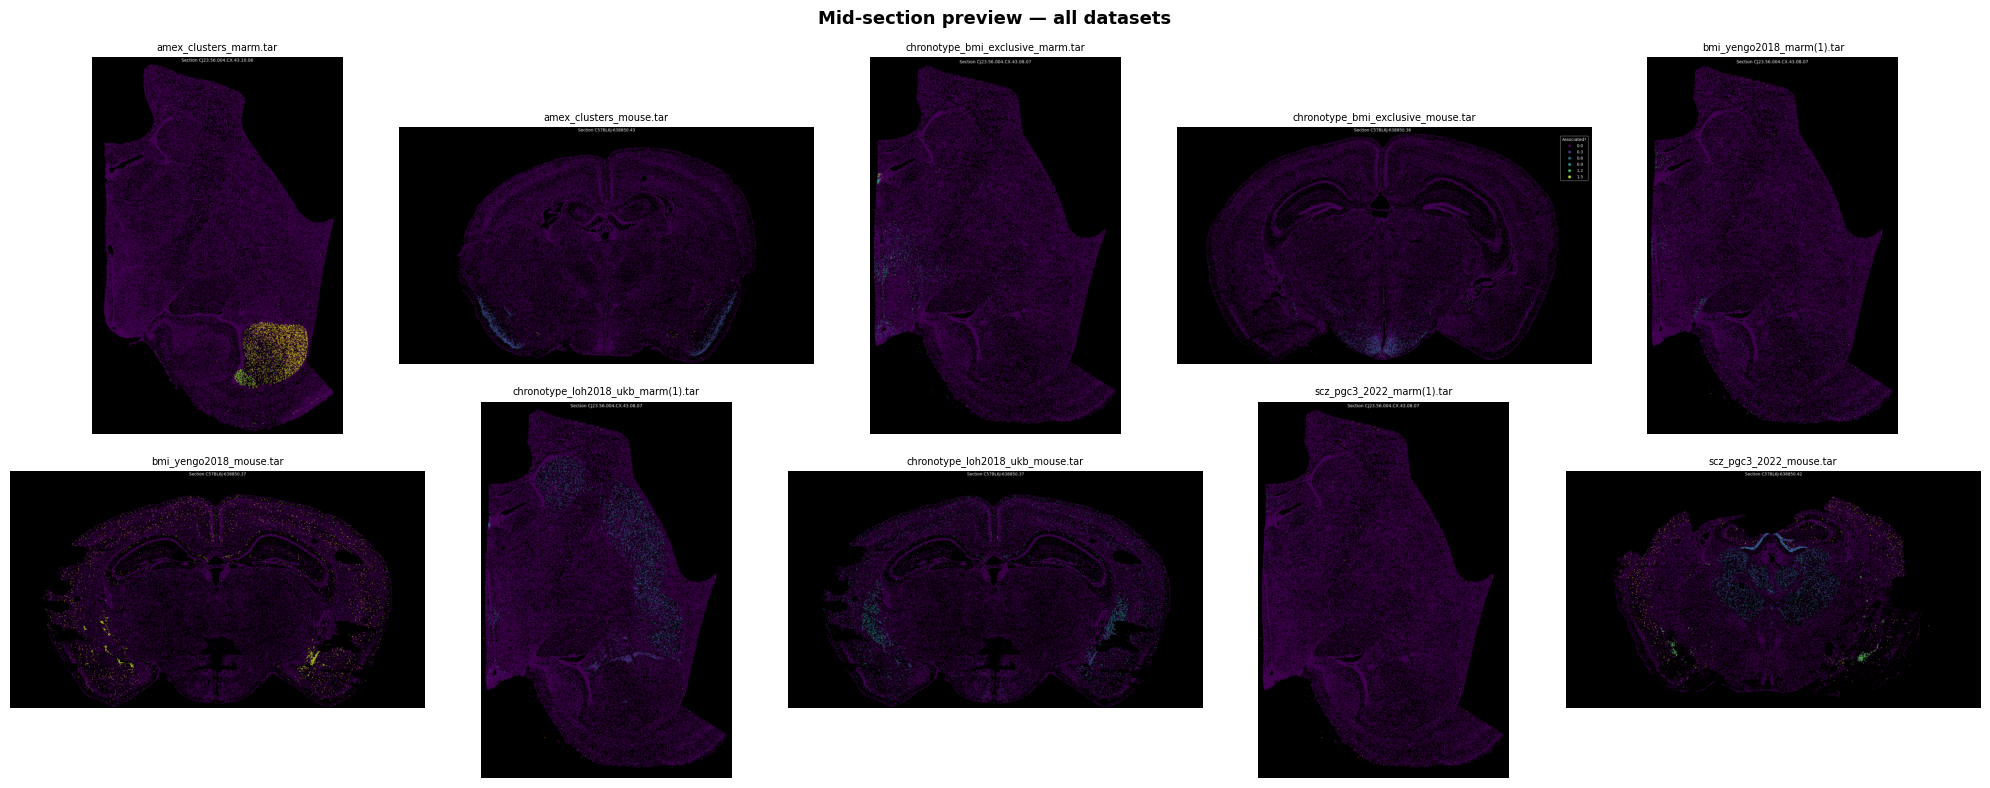

Preview saved → /root/capsule/code/abc_atlas_access/notebooks/flyby_videos_marmoset_coronal/all_datasets_preview.png


In [12]:
import matplotlib.pyplot as plt

ok = df[df['status'] == 'OK']
n  = len(ok)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten() if n > 1 else [axes]

for ax, (_, row) in zip(axes, ok.iterrows()):
    canon   = row['dataset']
    species = row['species']
    folder  = EXTRACT_DIR / canon
    records = collect_frames(folder, species)
    mid     = records[len(records) // 2]
    img     = iio.imread(mid['path'])
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    short = canon.replace('independent_clusters_', '').replace('_2d_all', '')
    ax.set_title(short, fontsize=7, wrap=True)
    ax.axis('off')

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Mid-section preview — all datasets', fontsize=13, fontweight='bold')
plt.tight_layout()
preview_path = OUTPUT_DIR / 'all_datasets_preview.png'
plt.savefig(preview_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Preview saved → {preview_path}')